| Collection ID | Band(s) | Spatial Resolution | Temporal Resolution |
|---|---|---|---|
| modis-aqua-myd13a1 | 500m 16 days NDVI | 500 m | 16 days |
| modis-aqua-myd15a2h | Lai_500m, Fpar_500m | 500 m | 8 days |
| modis-aqua-myd17a2h | Gpp_500m | 500 m | 8 days |
| modis-aqua-myd17a3hgf | Npp_500m | 500 m | Annual |

In [ ]:
test_aoi = {
  "type": "FeatureCollection",
  "features": [
    {
      "type": "Feature",
      "properties": {},
      "geometry": {
        "type": "Polygon",
        "coordinates": [
          [
            [5.05, 51.21],
            [5.1, 51.21],
            [5.1, 51.23],
            [5.05, 51.23],
            [5.05, 51.21]
          ]
        ]
      }
    }
  ]
}
test_date = ["2024-01-01", "2024-01-31"]

# Carbon update across Europe

In this notebook, we want to present a simple usecase to explore carbon uptake by vegetation across Europe using openEO. Specifically, we want to use the MODIS data to check whether greener vegetation actually produces more carbon. In other words, does higher NDVI correspond to higher GPP (Gross Primary Productivity, a measure of carbon captured through photosynthesis)?

Using the GPP and LAI products from MODIS data, we will also compute the carbon uptake efficiency in the cloud, leveraging the openEO's cloud-processing capability.


Let us first connect to the openEO CDSE backend that offers several MODIS products. To explore more on about the data that are avilable in the CDSE STAC catalogue please visit [this notebook](./MODIS_data_using_openEO.ipynb).

In [2]:
import openeo

connection = openeo.connect("openeo-staging.dataspace.copernicus.eu").authenticate_oidc()

Authenticated using refresh token.


In [3]:
# as feature collection 
europe_polygon = {
    "type": "FeatureCollection",
    "features": [
        {
            "type": "Feature",
            "geometry": {
                "type": "Polygon",
                "coordinates": [
                    [
                        [-10.0, 35.0],
                        [30.0, 35.0],
                        [30.0, 72.0],
                        [-10.0, 72.0],
                        [-10.0, 35.0]
                    ]
                ]
            },
            "properties": {}
        }
    ]
}
temporal_extent = ["2025-01-01", "2025-12-31"]

Since this notebooks uses several different MODIS products, it is convenient to wrap the STAC-loading logic in a small helper function that takes a collection ID and a list of bands, and returns the corresponding data cube for our area and time range.

In [4]:
def get_stac_cube(collection, bands):
    url = f"https://stac.dataspace.copernicus.eu/v1/collections/{collection}"
    stac_cube = connection.load_stac(url,
                                    temporal_extent=test_date,
                                    spatial_extent=test_aoi,
                                    bands=bands
                                    )
    return stac_cube

First, let us fetch the NDVI product, our proxy for vegetation greenness. This product can be used to answer the question "Does greener vegetation produce more carbon?" This MODIS product is generated as a 16-day composite.

In [ ]:
collection_id1 = "modis-aqua-myd13a1"
bands1 = ["500m 16 days NDVI"]
ndvi_cube = get_stac_cube(collection_id1, bands1)

To compare NDVI with GPP later, let us reduce this to a single time series by spatially aggregating over our area of interest, taking the mean NDVI per time step.

In [8]:
ndvi_ts = ndvi_cube.band("500m 16 days NDVI").aggregate_spatial(
    geometries=test_aoi,
    reducer="mean"
)

In [ ]:
ndvi_ts.execute_batch(title="NDVI timeseries", outputfile="carbon/ndvi_timeseries.csv")

0:00:00 Job 'j-2607170707054f749deb4ce7ce041fb8': send 'start'
0:00:01 Job 'j-2607170707054f749deb4ce7ce041fb8': queued (progress 0%)
0:00:07 Job 'j-2607170707054f749deb4ce7ce041fb8': queued (progress 0%)
0:00:13 Job 'j-2607170707054f749deb4ce7ce041fb8': queued (progress 0%)
0:00:21 Job 'j-2607170707054f749deb4ce7ce041fb8': queued (progress 0%)
0:00:31 Job 'j-2607170707054f749deb4ce7ce041fb8': queued (progress 0%)
0:00:43 Job 'j-2607170707054f749deb4ce7ce041fb8': queued (progress 0%)
0:00:59 Job 'j-2607170707054f749deb4ce7ce041fb8': queued (progress 0%)
0:01:18 Job 'j-2607170707054f749deb4ce7ce041fb8': running (progress 11.5%)
0:01:42 Job 'j-2607170707054f749deb4ce7ce041fb8': running (progress 14.5%)
0:02:12 Job 'j-2607170707054f749deb4ce7ce041fb8': finished (progress 100%)


<BatchJob job_id='j-2607170707054f749deb4ce7ce041fb8'>

Let us inspect the resulting NDVI time series.

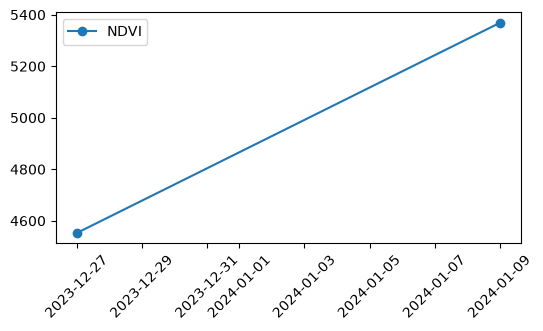

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("carbon/ndvi_timeseries.csv", index_col=0)
df.index = pd.to_datetime(df.index)
df = df.sort_index()
plt.figure(figsize=(6, 3))
plt.plot(df.index, df["band_unnamed"], label="NDVI",marker="o")
plt.xticks(rotation=45)
plt.legend()
plt.show()

Next, let us fetch the GPP for comparision, and our proxy for actual carbon uptake. This product comes as an 8-day composite, a finer temporal resolution than NDVI.

In [ ]:
collection_id3 = "modis-aqua-myd17a2h"
bands3 = ["Gpp_500m"]
gpp = get_stac_cube(collection_id3, bands3)

To bring GPP onto a comparable time step for the NDVI-vs-GPP comparison, let's aggregate the 8-day composites up to an annual mean using `aggregate_temporal_period`.

In [36]:
mean_gpp = gpp.band("Gpp_500m").aggregate_temporal_period(
    period="year",
    reducer="mean"
)

In [ ]:
mean_gpp.execute_batch(title="Mean GPP", outputfile="carbon/mean_gpp.nc")

0:00:00 Job 'j-2607170730014b878246d05065ccf9fb': send 'start'
0:00:02 Job 'j-2607170730014b878246d05065ccf9fb': created (progress 0%)
0:00:07 Job 'j-2607170730014b878246d05065ccf9fb': queued (progress 0%)
0:00:13 Job 'j-2607170730014b878246d05065ccf9fb': queued (progress 0%)
0:00:21 Job 'j-2607170730014b878246d05065ccf9fb': queued (progress 0%)
0:00:31 Job 'j-2607170730014b878246d05065ccf9fb': queued (progress 0%)
0:00:44 Job 'j-2607170730014b878246d05065ccf9fb': queued (progress 0%)
0:00:59 Job 'j-2607170730014b878246d05065ccf9fb': queued (progress 0%)
0:01:18 Job 'j-2607170730014b878246d05065ccf9fb': running (progress 11.4%)
0:01:42 Job 'j-2607170730014b878246d05065ccf9fb': running (progress 14.5%)
0:02:13 Job 'j-2607170730014b878246d05065ccf9fb': finished (progress 100%)


<BatchJob job_id='j-2607170730014b878246d05065ccf9fb'>

Does greener vegetation actually produce more carbon?

Mean NDVI on x-axis

Mean GPP on y-axis

expected low NDVI  -> low GPP
high NDVI -> high GPP

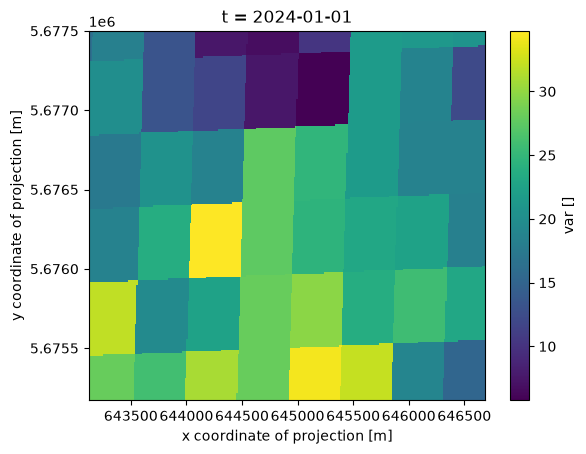

In [6]:
import matplotlib.pyplot as plt
import xarray as xr

ds = xr.open_dataset("mean_gpp.nc")
ds["var"].plot()

Finally, let us access the LAI product, available as 8-day composites. We need LAI specifically for the carbon uptake efficiency calculation: GPP / LAI. This parameter helps us understanding on how much carbon is captured per unit of leaf area, rather than just per unit of greenness.

In [ ]:
# secondly LAI/FPAR products; these are 8 day composites

collection_id2 = "modis-aqua-myd15a2h"
bands2 = ["Lai_500m"]
lai_fpar = get_stac_cube(collection_id2, bands2)

Note that `gpp` and `lai_fpar` are still two separate datacubes at this point, so dividing them directly doesn't align their bands or dimensions properly, so this result isn't reliable yet. The correct approach is to merge the two cubes first with `merge_cubes`, so their dimensions are aligned, and only then select and divide the specific bands we need to get carbon uptake efficiency.

In [ ]:
# carbon_uptake = gpp/ lai_fpar.band("Lai_500m")

merged_cube = gpp.merge_cubes(lai_fpar)
carbon_uptake_v2 = merged_cube.band("Gpp_500m")/ merged_cube.band("Lai_500m")

In [ ]:
carbon_uptake.execute_batch(title="Carbon Uptake", outputfile="carbon/carbon_uptake.nc")

0:00:00 Job 'j-2607170720544caaaf09e39c29b65c6b': send 'start'
0:00:01 Job 'j-2607170720544caaaf09e39c29b65c6b': created (progress 0%)
0:00:07 Job 'j-2607170720544caaaf09e39c29b65c6b': queued (progress 0%)
0:00:13 Job 'j-2607170720544caaaf09e39c29b65c6b': running (progress 2.1%)
0:00:21 Job 'j-2607170720544caaaf09e39c29b65c6b': running (progress 3.4%)
0:00:31 Job 'j-2607170720544caaaf09e39c29b65c6b': running (progress 4.9%)
0:00:43 Job 'j-2607170720544caaaf09e39c29b65c6b': running (progress 6.7%)
0:00:59 Job 'j-2607170720544caaaf09e39c29b65c6b': running (progress 8.9%)
0:01:18 Job 'j-2607170720544caaaf09e39c29b65c6b': finished (progress 100%)


<BatchJob job_id='j-2607170720544caaaf09e39c29b65c6b'>

In [ ]:
import xarray as xr
carbon_uptake_ds = xr.open_dataset("carbon/carbon_uptake.nc")
carbon_uptake_ds

<xarray.Dataset> Size: 2MB
Dimensions:   (t: 5, x: 357, y: 233)
Coordinates:
  * t         (t) datetime64[ns] 40B 2023-12-27 2024-01-01 ... 2024-01-25
  * x         (x) float64 3kB 6.431e+05 6.431e+05 ... 6.467e+05 6.467e+05
  * y         (y) float64 2kB 5.677e+06 5.677e+06 ... 5.675e+06 5.675e+06
Data variables:
    crs       |S1 1B ...
    Gpp_500m  (t, y, x) float32 2MB ...
Attributes:
    Conventions:  CF-1.9
    institution:  Copernicus Data Space Ecosystem openEO API - 0.73.0a16.dev2...
    description:  
    title:

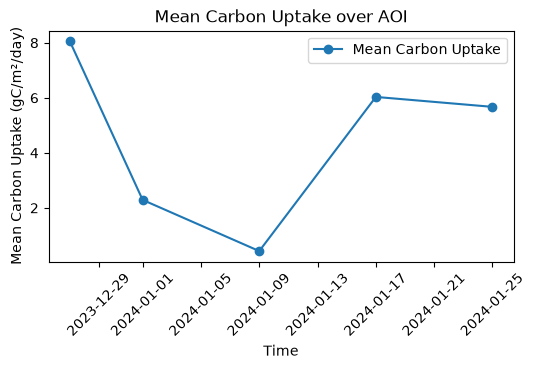

In [34]:
# plot mean carbon uptake over the AOI
carbon_uptake_var = next(
    data_array
    for _, data_array in carbon_uptake_ds.data_vars.items()
    if {"x", "y"}.issubset(data_array.dims)
    and data_array.dtype.kind in "fiu"
    and "t" in data_array.dims
)
mean_carbon_uptake = carbon_uptake_var.mean(dim=["x", "y"], skipna=True)
plt.figure(figsize=(6, 3))
plt.plot(mean_carbon_uptake.t, mean_carbon_uptake, label="Mean Carbon Uptake", marker="o")
plt.xticks(rotation=45)
plt.xlabel("Time")
plt.ylabel("Mean Carbon Uptake (gC/m²/day)")
plt.title("Mean Carbon Uptake over AOI")
plt.legend()
plt.show()

Once downloaded, the NDVI and GPP time series can be plotted against each other (NDVI on the x-axis, GPP on the y-axis) to check the greenness-vs-carbon relationship, and the carbon uptake efficiency layer can be mapped to see where vegetation is capturing carbon most efficiently relative to its leaf area; this is where the broader use case comes together: showing how MODIS data on CDSE can support carbon monitoring workflows.